In [26]:
import pandas as pd 
import matplotlib as mlt
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("vehicle_price_prediction.csv")

print(df.head())

         make       model  year  mileage  engine_hp transmission fuel_type  \
0  Volkswagen       Jetta  2016   183903        173       Manual  Electric   
1       Lexus          RX  2010   236643        352       Manual  Gasoline   
2      Subaru   Crosstrek  2016   103199        188    Automatic    Diesel   
3    Cadillac       Lyriq  2016   118889        338       Manual  Gasoline   
4      Toyota  Highlander  2018   204170        196       Manual    Diesel   

  drivetrain body_type exterior_color interior_color  owner_count  \
0        RWD     Sedan           Blue          Brown            5   
1        FWD     Sedan         Silver          Beige            5   
2        AWD     Sedan         Silver          Beige            5   
3        AWD       SUV          Black           Gray            3   
4        FWD     Sedan            Red          Brown            5   

  accident_history seller_type  condition     trim  vehicle_age  \
0              NaN      Dealer  Excellent       E

In [4]:
df.shape

(1000000, 20)

In [11]:
# df.describe()

cols = df[["price", "accident_history", "mileage", "year"]]

del cols

In [39]:
df['accident_history'].isna()

0          True
1         False
2          True
3          True
4         False
          ...  
999995     True
999996    False
999997     True
999998     True
999999     True
Name: accident_history, Length: 1000000, dtype: bool

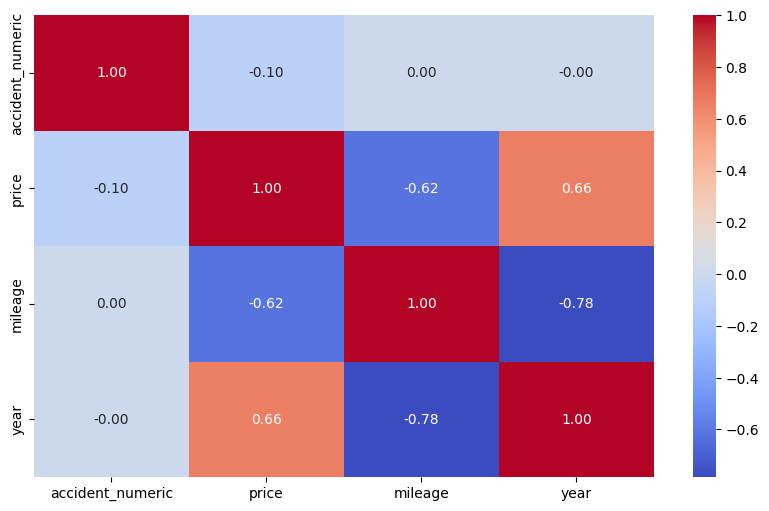

In [ ]:
df["accident_numeric"] = df["accident_history"].fillna('None').map({'None' : 0, 'Minor': 1, 'Major':2})

cols = df[["accident_numeric", 'price', "mileage", 'year']]
# print(cols)


corr = cols.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()






In [45]:
import plotly.express as px

fig = px.scatter_3d(df, x="price", y="accident_numeric", z="mileage",
                    hover_name=df.index,
                    opacity=0.5)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [34]:
# max_years = df["year"].max()

# print(max_years)

# print(df[cols].head())
df.dtypes

make                    str
model                   str
year                  int64
mileage               int64
engine_hp             int64
transmission            str
fuel_type               str
drivetrain              str
body_type               str
exterior_color          str
interior_color          str
owner_count           int64
accident_history        str
seller_type             str
condition               str
trim                    str
vehicle_age           int64
mileage_per_year    float64
brand_popularity    float64
price               float64
accident_numeric    float64
dtype: object

<Axes: >

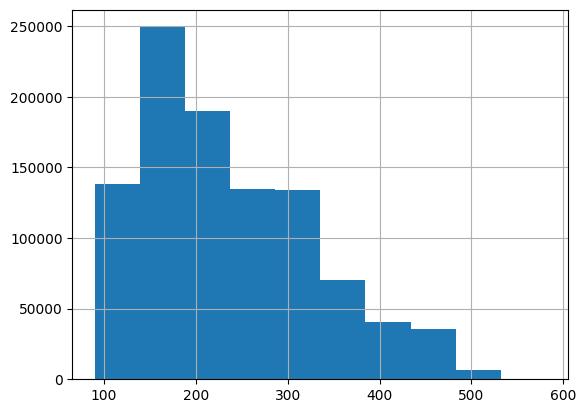

In [7]:
df["engine_hp"].hist()

<Axes: title={'center': 'year'}, xlabel='vehicle_age'>

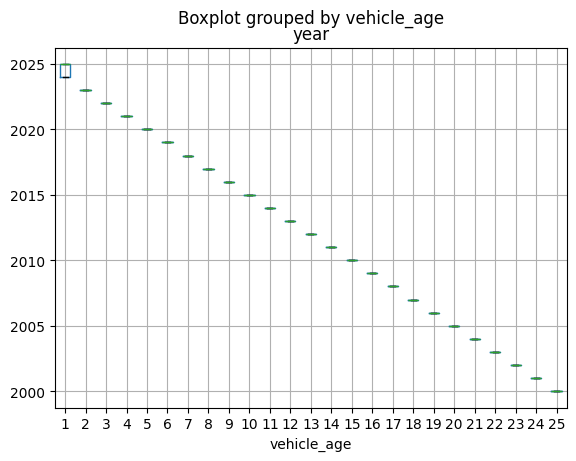

In [8]:
df.boxplot(column = "year", by = "vehicle_age" )



In [9]:
df.isnull().sum()

make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64

In [2]:
import matplotlib.pyplot as plt
accident = df["accident_history"].isnull()
# print(accident)

# for value in accident:
#     if value == False:
#         print(value)

accident.value_counts().plot(kind = "bar", color=['blue', 'pink'])
plt.xticks(ticks=[0,1], labels = ['True', 'False'], rotation=0)   
plt.ylabel('frequency')
plt.show()  


NameError: name 'df' is not defined

In [11]:
matrix_df = df.pivot(index="price", columns="mileage", values="accident_history")

sns.heatmap(matrix_df, annot=True, cmap='coolwarm')
plt.show()

C:\Users\Installer\AppData\Local\Temp\ipykernel_17212\298446231.py:1: PerformanceWarning: The following operation may generate 218727142248 cells in the resulting pandas object.
  matrix_df = df.pivot(index="price", columns="mileage", values="accident_history")


MemoryError: Unable to allocate 204. GiB for an array with shape (218727142248,) and data type bool

            price   mileage      year
price    1.000000 -0.618349  0.664730
mileage -0.618349  1.000000 -0.784029
year     0.664730 -0.784029  1.000000


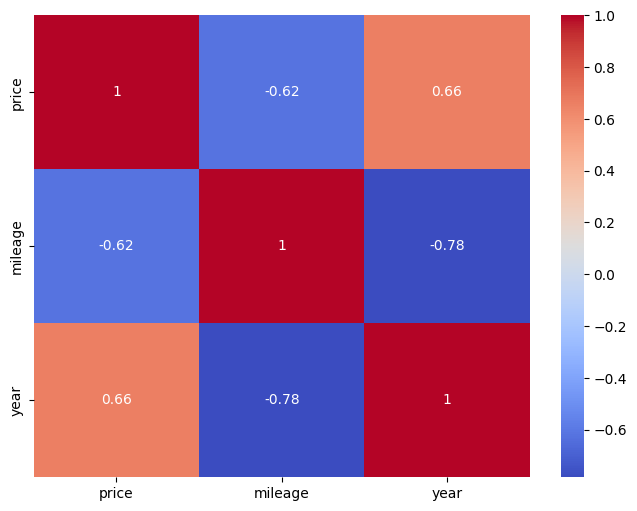

In [ ]:
correlation_matrix = df[["price", "mileage", "year"]].corr()


print(correlation_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
sns.pairplot(df[["price", "year"]],kind="kde")

<Axes: >

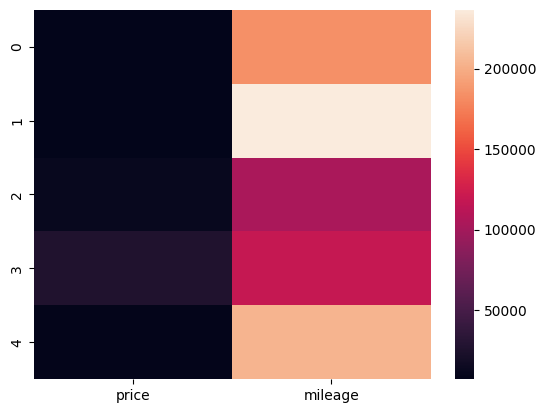

In [9]:
sns.heatmap(df[["price", "mileage"]].head())